# EMBER: Evacuation Behaviour Inference — Marshall Fire

**Fire**: Marshall Fire, Boulder County, Colorado  
**Date**: December 30, 2021 (~10:13 MST ignition)  

## Schema differences vs. LA Fire dataset

| Item | LA Fire | Marshall Fire |
|------|---------|---------------|
| User ID column | `ID` | `GRID` |
| Latitude column | `LAT` | `GEOHASHLAT` |
| Longitude column | `LONG` | `GEOHASHLONG` |
| Timestamp column | `TIMESTAMP` (ms epoch int) | `TIMESTAMP_EPOCH_MILLISECOND` (ISO datetime string) |
| Home CRS | `home_lat/lon_4326` | `home_lat/lon_3857` → must reproject |
| DAU files | 1 CSV | 3 CSVs (concatenated) |
| Evac zones | GeoJSON timeline | `evacuation_area/Everbridge_Notification_Areas.shp` |
| Zone column | `most_extreme_status` | `EvacStatus` (values: `eva_order` / `eva_warning`) |
| Buffer | 2 km | 8 km |

## Pipeline
```
home.csv (3857) ──reproject──► gpd.GeoDataFrame (4326)
                                      │
evacuation_area.shp ─────────► ember.zones.classify_zones()
                                      │
dau_during_fire[1-3].csv ─────► ember.pipeline.compute_stops()
                                      │
                              ember.pipeline.infer_metrics()
                                      │
                              Visualisations + CSV output
```

---
## 1 · Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Make EMBER importable when running from examples/
sys.path.insert(0, os.path.abspath('..'))

import importlib
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer

# EMBER modules
import ember.io         as eio
import ember.zones      as ezones
import ember.pipeline   as epipe
import ember.metrics    as emetrics
import ember.behavior   as ebehavior

for mod in [eio, ezones, epipe, emetrics, ebehavior]:
    importlib.reload(mod)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = os.path.join(os.getcwd(), 'data', 'marshall_data')
DAU_DIR  = os.path.join(DATA_DIR, 'daily active user')
SHP_FILE = os.path.join(DATA_DIR, 'shapefile', 'evacuation_area',
                        'Everbridge_Notification_Areas.shp')
HOME_CSV = os.path.join(DATA_DIR, 'home.csv')

print('DATA_DIR :', DATA_DIR)
print('SHP_FILE :', SHP_FILE)
print('HOME_CSV :', HOME_CSV)
print('DAU files:', sorted(os.listdir(DAU_DIR)))

DATA_DIR : /Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/data/marshall_data
SHP_FILE : /Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/data/marshall_data/shapefile/evacuation_area/Everbridge_Notification_Areas.shp
HOME_CSV : /Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/data/marshall_data/home.csv
DAU files: ['dau_during_fire1.csv', 'dau_during_fire2.csv', 'dau_during_fire3.csv']


---
## 2 · Load & Inspect Raw Data

In [2]:
# 2a ── Home locations (EPSG:3857 → reproject to 4326)
homes_raw = pd.read_csv(HOME_CSV)
print('Home columns:', list(homes_raw.columns))
print('Rows:', len(homes_raw))
homes_raw.head(3)

Home columns: ['ID', 'home_lat_3857', 'home_lon_3857']
Rows: 147804


,ID,home_lat_3857,home_lon_3857
0,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,-11687900.0,4850820.0
1,238ff64e-bf78-39d9-b4a2-ab09ac9e561b,-11696080.0,4874740.0
2,23900039-6595-3a05-a9e6-c9fd6db9f767,-11693000.0,4807400.0


In [3]:
# Reproject 3857 → 4326
tf = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
lons, lats = tf.transform(homes_raw['home_lat_3857'].values,\
                           homes_raw['home_lon_3857'].values)
homes_raw['home_lon_4326'] = lons
homes_raw['home_lat_4326'] = lats

homes = gpd.GeoDataFrame(
    homes_raw,
    geometry=gpd.points_from_xy(homes_raw['home_lon_4326'],
                                 homes_raw['home_lat_4326']),
    crs='EPSG:4326'
)
print(f'{len(homes):,} home locations loaded')
homes[['ID','home_lat_4326','home_lon_4326']].head(3)

147,804 home locations loaded


,ID,home_lat_4326,home_lon_4326
0,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895857,-104.994192
1,238ff64e-bf78-39d9-b4a2-ab09ac9e561b,40.060515,-105.067674
2,23900039-6595-3a05-a9e6-c9fd6db9f767,39.595954,-105.040006


In [4]:
# 2b ── Evacuation zones (Everbridge shapefile)
eva_area = gpd.read_file(SHP_FILE).to_crs(epsg=3857)
print('Shapefile CRS:', eva_area.crs)
print('Columns:', list(eva_area.columns))
print('Row count:', len(eva_area))
eva_area.head()

Shapefile CRS: EPSG:3857
Columns: ['INCIDENTNM', 'DESCRIPTIO', 'EVACURL', 'GlobalID', 'EvacStatus', 'EvacZoneNa', 'Shape__Are', 'Shape__Len', 'geometry']
Row count: 51


,INCIDENTNM,DESCRIPTIO,EVACURL,GlobalID,EvacStatus,EvacZoneNa,Shape__Are,Shape__Len,geometry
0,Marshall Fire,All Clear,https://www.boulderoem.com/emergency-status/,{1A387200-DDD8-486B-A25D-95351C749651},All Clear,None,1.237941e+07,33338.463593,"POLYGON ((-11702803.15 4859293.737, -11703857...."
1,Marshall Fire,All Clear,https://www.boulderoem.com/emergency-status/,{58A57DDA-025B-44FB-BA0A-15E72D4F2499},All Clear,None,7.578357e+03,645.712808,"POLYGON ((-11706739.918 4861390.55, -11706743...."
2,Marshall Fire,All Clear,https://www.boulderoem.com/emergency-status/,{FC399825-4C4D-4851-9F05-47A5735572AA},All Clear,None,1.934292e+07,23197.012942,"POLYGON ((-11712186.501 4866467.138, -11711201..."
3,Marshall Fire,All Clear,https://www.boulderoem.com/emergency-status/,{B1C96892-D2DD-4F5A-9647-3CBC9DFEB2B6},All Clear,None,2.304959e+05,2047.858928,"POLYGON ((-11706266.37 4859277.204, -11706931...."
4,Marshall Fire,All Clear,https://www.boulderoem.com/emergency-status/,{9921F5EF-6338-4356-9848-D9590E9ED0EE},All Clear,None,8.142564e+06,14531.748535,"POLYGON ((-11704937.398 4855810.366, -11704794..."


In [5]:
# Zone classification exactly as in Yuran's notebook:
# Drop unused columns (adjust if your file differs)
drop_cols = [c for c in ['INCIDENTNM','DESCRIPTIO','EVACURL','EvacZoneNa'] if c in eva_area.columns]
eva_area = eva_area.drop(columns=drop_cols)

# Default: all rows are eva_order
eva_area['EvacStatus'] = 'eva_order'
eva_area['idx'] = eva_area.index

# Rows that are eva_warning (from Yuran's original code)
WARNING_ROWS = [2, 4, 15, 16, 17, 18, 20, 21]
valid_warning = [r for r in WARNING_ROWS if r in eva_area.index]
eva_area.loc[valid_warning, 'EvacStatus'] = 'eva_warning'

print('EvacStatus distribution:')
print(eva_area['EvacStatus'].value_counts())

order_zone   = eva_area[eva_area['EvacStatus'] == 'eva_order']
warning_zone = eva_area[eva_area['EvacStatus'] == 'eva_warning']
print(f'Order zones: {len(order_zone)}  Warning zones: {len(warning_zone)}')

EvacStatus distribution:
EvacStatus
eva_order      43
eva_warning     8
Name: count, dtype: int64
Order zones: 43  Warning zones: 8


In [6]:
# 2c ── Build ~8 km buffer (as in Yuran's notebook)
buffer = eva_area.copy()
buffer['geometry'] = buffer.geometry.buffer(2000)   # metres in EPSG:3857
polygon_buffer = buffer.geometry.unary_union
buffer_gdf = gpd.GeoDataFrame(geometry=[polygon_buffer], crs=buffer.crs)
print('Buffer created:', buffer_gdf)

# Buffer-only zone (outside evacuation zone)
eva_buf = eva_area.copy()
eva_buf['geometry'] = eva_buf.geometry.buffer(0)
polygon_eva = eva_buf.geometry.unary_union
eva_boundary = gpd.GeoDataFrame(geometry=[polygon_eva], crs=eva_buf.crs)
buf_only = gpd.overlay(df1=eva_boundary, df2=buffer_gdf, how='symmetric_difference')
print('Buffer-only zone:', buf_only)

Buffer created:                                             geometry
0  POLYGON ((-11714830.111 4856295.387, -11715031...
Buffer-only zone:                                             geometry
0  MULTIPOLYGON (((-11715031.132 4856306.42, -117...


---
## 3 · Adapt Zone Shapefile for EMBER

EMBER's `classify_zones()` expects `most_extreme_status` (values: `Evacuation Order` / `Evacuation Warning`)
and a `datetime` column.  We create both from the Everbridge shapefile.

In [7]:
# Marshall Fire ignited 2021-12-30 ~10:13 MST = 17:13 UTC
FIRE_DATE = pd.Timestamp('2021-12-30 17:13:00', tz='UTC')

# Map Everbridge EvacStatus → EMBER vocabulary
STATUS_MAP = {'eva_order': 'Evacuation Order', 'eva_warning': 'Evacuation Warning'}

fire_zones = eva_area.to_crs(epsg=4326).copy()
fire_zones['most_extreme_status'] = fire_zones['EvacStatus'].map(STATUS_MAP)
fire_zones['zoneId']        = fire_zones['GlobalID'].astype(str)
fire_zones['incident_name'] = 'Marshall'
fire_zones['datetime']      = FIRE_DATE

# Per-zone order/warning lift dates (from Yuran's fire timeline)
# Each zone has its own date when the order/warning was lifted.
ZONE_END_DATES = {
    0: '2022-01-01', 2: '2022-01-05', 3: '2022-01-05',
    4: '2021-12-31', 6: '2022-01-01', 7: '2022-01-01',
    8: '2022-01-05', 9: '2022-01-01', 10: '2022-01-05',
    12: '2022-01-05', 13: '2022-01-05', 14: '2022-01-05',
    16: '2022-01-05', 17: '2022-01-02', 18: '2022-01-01',
    19: '2022-01-05', 22: '2022-01-05', 23: '2022-01-05',
    24: '2022-01-05', 25: '2022-01-05', 26: '2022-01-05',
    30: '2022-01-05', 32: '2022-01-05', 36: '2022-01-05',
    41: '2022-01-05', 42: '2022-01-05', 44: '2022-01-05',
    46: '2022-01-05', 47: '2022-01-05', 48: '2022-01-05',
    50: '2022-01-05',
}
fire_zones['OrderEnd'] = fire_zones['idx'].map(ZONE_END_DATES)
fire_zones['OrderEnd'] = pd.to_datetime(fire_zones['OrderEnd'])

print('Zones ready for EMBER:')
print(fire_zones['most_extreme_status'].value_counts())
fire_zones[['zoneId','most_extreme_status','incident_name','datetime','OrderEnd']].head()

Zones ready for EMBER:
most_extreme_status
Evacuation Order      43
Evacuation Warning     8
Name: count, dtype: int64


,zoneId,most_extreme_status,incident_name,datetime,OrderEnd
0,{1A387200-DDD8-486B-A25D-95351C749651},Evacuation Order,Marshall,2021-12-30 17:13:00+00:00,2022-01-01
1,{58A57DDA-025B-44FB-BA0A-15E72D4F2499},Evacuation Order,Marshall,2021-12-30 17:13:00+00:00,NaT
2,{FC399825-4C4D-4851-9F05-47A5735572AA},Evacuation Warning,Marshall,2021-12-30 17:13:00+00:00,2022-01-05
3,{B1C96892-D2DD-4F5A-9647-3CBC9DFEB2B6},Evacuation Order,Marshall,2021-12-30 17:13:00+00:00,2022-01-05
4,{9921F5EF-6338-4356-9848-D9590E9ED0EE},Evacuation Warning,Marshall,2021-12-30 17:13:00+00:00,2021-12-31


---
## 4 · Classify Home Zones

In [8]:
zoned_homes = ezones.classify_zones(homes, fire_zones, buffer_distance=2000)
print(f'{len(zoned_homes):,} residents zoned')
print(zoned_homes['ZoneType'].value_counts())
zoned_homes[['ID','ZoneType','OrderStart','home_lon_4326','home_lat_4326']].head()

147,804 residents zoned
ZoneType
Outside    145543
Buffer        970
Order         672
Warning       619
Name: count, dtype: int64


,ID,ZoneType,OrderStart,home_lon_4326,home_lat_4326
1153,51309761-7849-39f5-b552-b0807726cc35,Order,2021-12-30 17:13:00+00:00,-105.158404,39.967909
1185,513d94c8-e8f7-3834-bf9a-e62691e84f70,Order,2021-12-30 17:13:00+00:00,-105.150319,39.984430
1422,45257c47-63fd-3e4d-9205-7147e98973ac,Order,2021-12-30 17:13:00+00:00,-105.139899,39.971214
2030,5da71c32-f2d1-3cc8-a131-aeab727ca0d9,Order,2021-12-30 17:13:00+00:00,-105.150140,39.961437
2383,5fd8ba15-7905-3cb9-985c-9c09ca7d8141,Order,2021-12-30 17:13:00+00:00,-105.137563,39.969699


---
## 5 · Load & Normalise GPS Trajectories

Column mapping (Marshall → EMBER standard):

| Marshall | EMBER |
|----------|-------|
| `GRID` | `ID` |
| `GEOHASHLAT` | `LAT` |
| `GEOHASHLONG` | `LONG` |
| `TIMESTAMP_EPOCH_MILLISECOND` | `TIMESTAMP` (then parse as `datetime`) |

In [9]:
dau_files = sorted([
    os.path.join(DAU_DIR, f)
    for f in os.listdir(DAU_DIR) if f.endswith('.csv')
])
print(f'Found {len(dau_files)} DAU files:', [os.path.basename(f) for f in dau_files])

parts = []
for fp in dau_files:
    print(f'  Loading {os.path.basename(fp)} …', end=' ')
    chunk = pd.read_csv(fp, low_memory=False)
    print(f'{len(chunk):,} rows')
    parts.append(chunk)

dau_raw = pd.concat(parts, ignore_index=True)
print(f'\nTotal rows: {len(dau_raw):,}  |  Unique GRIDs: {dau_raw["GRID"].nunique():,}')
print('Columns:', list(dau_raw.columns))
dau_raw.head(3)

Found 3 DAU files: ['dau_during_fire1.csv', 'dau_during_fire2.csv', 'dau_during_fire3.csv']
  Loading dau_during_fire1.csv … 

70,423,161 rows
  Loading dau_during_fire2.csv … 

62,276,998 rows
  Loading dau_during_fire3.csv … 

69,333,248 rows



Total rows: 202,033,407  |  Unique GRIDs: 147,417
Columns: ['Unnamed: 0', 'GRID', 'GEOHASHLAT', 'GEOHASHLONG', 'GEOHASH9', 'TIMESTAMP_EPOCH_MILLISECOND', 'datetime', 'Date', 'hour']


,Unnamed: 0,GRID,GEOHASHLAT,GEOHASHLONG,GEOHASH9,TIMESTAMP_EPOCH_MILLISECOND,datetime,Date,hour
0,0,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895756,-104.994171,9xj6fyc9d,2021-12-30 07:00:02+00:00,2021-12-30 00:00:02,2021-12-30,0
1,1,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895756,-104.994299,9xj6fyc3x,2021-12-30 07:00:04+00:00,2021-12-30 00:00:04,2021-12-30,0
2,2,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895799,-104.994214,9xj6fyc9c,2021-12-30 07:00:08+00:00,2021-12-30 00:00:08,2021-12-30,0


In [10]:
# Rename to EMBER standard schema
dau = dau_raw.rename(columns={
    'GRID':                        'ID',
    'GEOHASHLAT':                  'LAT',
    'GEOHASHLONG':                 'LONG',
    'TIMESTAMP_EPOCH_MILLISECOND': 'TIMESTAMP',
})

# TIMESTAMP_EPOCH_MILLISECOND is an ISO datetime string in this dataset
# (unlike LA Fire where it was a numeric ms epoch)
dau['datetime'] = pd.to_datetime(dau['TIMESTAMP'], format='mixed', utc=True)
dau['hour']     = dau['datetime'].dt.hour

print(f'{len(dau):,} pings, {dau["ID"].nunique():,} unique devices')
print('Date range:', dau['datetime'].min(), '→', dau['datetime'].max())
dau[['ID','LAT','LONG','TIMESTAMP','datetime','Date','hour']].head(3)

202,033,407 pings, 147,417 unique devices


Date range: 2021-12-30 07:00:00+00:00 → 2022-01-06 23:59:59+00:00


,ID,LAT,LONG,TIMESTAMP,datetime,Date,hour
0,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895756,-104.994171,2021-12-30 07:00:02+00:00,2021-12-30 07:00:02+00:00,2021-12-30,7
1,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895756,-104.994299,2021-12-30 07:00:04+00:00,2021-12-30 07:00:04+00:00,2021-12-30,7
2,238f6a1d-a3b6-326d-b8df-70d7b51afb2a,39.895799,-104.994214,2021-12-30 07:00:08+00:00,2021-12-30 07:00:08+00:00,2021-12-30,7


---
## 6 · Compute Stops

In [11]:
stops = epipe.compute_stops(
    dau, zoned_homes, fire_zones,
    buffer_meters=2000,
    verbose=True
)
print(f'\n{len(stops):,} stop records')
stops.head(3)

Computing stops for 2,261 residents (2,893,993 pings) …


  → 2,893,993 stop records ready

2,893,993 stop records


,Unnamed: 0,ID,LAT,LONG,GEOHASH9,TIMESTAMP,datetime,Date,hour,home_lon,...,ZoneType,OrderStart,FireEvent,OrderEnd,stop_date,lat_grid,lon_grid,dist_meters,eu_distance,is_outside_zone
0,38689558,00098631-d113-3c6a-892e-bd0ffc0842be,39.977338,-105.231192,9xj5mmsuz,2021-12-30 07:00:07+00:00,2021-12-30 07:00:07+00:00,2021-12-30,7,-11714280.0,...,Buffer,NaT,NaN,NaT,2021-12-30 07:00:07+00:00,39.977338,-105.231192,10.018892,0.006225,False
1,38689559,00098631-d113-3c6a-892e-bd0ffc0842be,39.977295,-105.231192,9xj5mmsux,2021-12-30 07:00:57+00:00,2021-12-30 07:00:57+00:00,2021-12-30,7,-11714280.0,...,Buffer,NaT,NaN,NaT,2021-12-30 07:00:57+00:00,39.977295,-105.231192,4.346586,0.002701,False
2,38689560,00098631-d113-3c6a-892e-bd0ffc0842be,39.998624,-105.257671,9xj5sc98y,2021-12-30 08:03:16+00:00,2021-12-30 08:03:16+00:00,2021-12-30,8,-11714280.0,...,Buffer,NaT,NaN,NaT,2021-12-30 08:03:16+00:00,39.998624,-105.257671,4281.228007,2.660231,True


---
## 7 · Infer Evacuation Metrics

**Marshall Fire timeline:**
- Fire ignition: 2021-12-30 ~10:13 MST
- Evacuation orders (mandatory): quickly issued for Superior & parts of Louisville ~11 AM MST
- Study window: 2021-12-30 through 2022-01-06

In [12]:
FIRE_STARTS = {'Marshall': '2021-12-30 10:13'}  # local MST
FIRE_END    = '2022-01-06'

metrics = epipe.infer_metrics(
    stops,
    fire_starts=FIRE_STARTS,
    fire_end=FIRE_END,
    min_dist_miles=0.25,
    min_evac_days=2,          # in-zone: >1 day per paper (Sun et al.)
    min_evac_days_buffer=1,   # buffer: N=1 for Marshall per paper
    verbose=True,
)
metrics.head(5)

Inferring metrics for 2,251 residents …


  → 1,730 evacuees / 2,251 total
Category
SEFN    726
NER     521
SELE    452
PERE    220
FEUW    146
FEUO    143
UR       43


,ID,Category,DepartureDate,ReturnDate,DelayHours,ZoneType,OrderStart,OrderEnd,FireEvent,fire_start,home_lon,is_evacuee
0,00098631-d113-3c6a-892e-bd0ffc0842be,SELE,2021-12-30 08:03:16+00:00,2022-01-06 23:59:27+00:00,0.000000,Buffer,2021-12-30 10:13:00+00:00,2022-01-06 23:00:00+00:00,NaN,2021-12-30 10:13:00+00:00,-11714280.0,True
1,0037d191-693e-3e85-aa3b-2229dd723c45,NER,NaT,NaT,NaN,Buffer,2021-12-30 10:13:00+00:00,2022-01-06 23:00:00+00:00,NaN,2021-12-30 10:13:00+00:00,-11712400.0,False
2,00707b47-73fe-399d-85d5-4fa90f44bbb7,PERE,2021-12-30 21:48:05+00:00,2022-01-04 17:28:35+00:00,4.584722,Warning,2021-12-30 17:13:00+00:00,2022-01-05 00:00:00+00:00,Marshall,2021-12-30 10:13:00+00:00,-11705660.0,True
3,00751ba1-3256-3e56-b0bb-2465d9754d7f,NER,NaT,NaT,NaN,Warning,2021-12-30 17:13:00+00:00,2022-01-05 00:00:00+00:00,Marshall,2021-12-30 10:13:00+00:00,-11704060.0,False
4,00891f7a-a5b1-35b5-a771-b1ea9983b348,SEFN,2021-12-31 06:31:44+00:00,2022-01-06 22:23:55+00:00,20.312222,Buffer,2021-12-30 10:13:00+00:00,2022-01-06 23:00:00+00:00,NaN,2021-12-30 10:13:00+00:00,-11700820.0,True


---
## 8 · Behaviour Summary

In [13]:
cat = metrics['Category'].value_counts()
pct = (cat / len(metrics) * 100).round(1)
print('=== Evacuation Behaviour Summary ===')
print(pd.DataFrame({'Count': cat, 'Pct (%)': pct}).to_string())

# Category legend
legend = {
    'FEUO':  'Full Evacuee (under Order)',
    'FEUW':  'Full Evacuee (under Warning)',
    'SELE':  'Self-Evacuee (before Order)',
    'SEFN':  'Self-Evacuee (Fire Nearby / buffer zone)',
    'PERE':  'Partial Evacuee (returned before order end)',
    'NER':   'Non-Evacuating Resident',
    'UR':    'Undetermined',
}
print('\nCategory legend:')
for k,v in legend.items(): print(f'  {k:6s} = {v}')

=== Evacuation Behaviour Summary ===
          Count  Pct (%)
Category                
SEFN        726     32.3
NER         521     23.1
SELE        452     20.1
PERE        220      9.8
FEUW        146      6.5
FEUO        143      6.4
UR           43      1.9

Category legend:
  FEUO   = Full Evacuee (under Order)
  FEUW   = Full Evacuee (under Warning)
  SELE   = Self-Evacuee (before Order)
  SEFN   = Self-Evacuee (Fire Nearby / buffer zone)
  PERE   = Partial Evacuee (returned before order end)
  NER    = Non-Evacuating Resident
  UR     = Undetermined


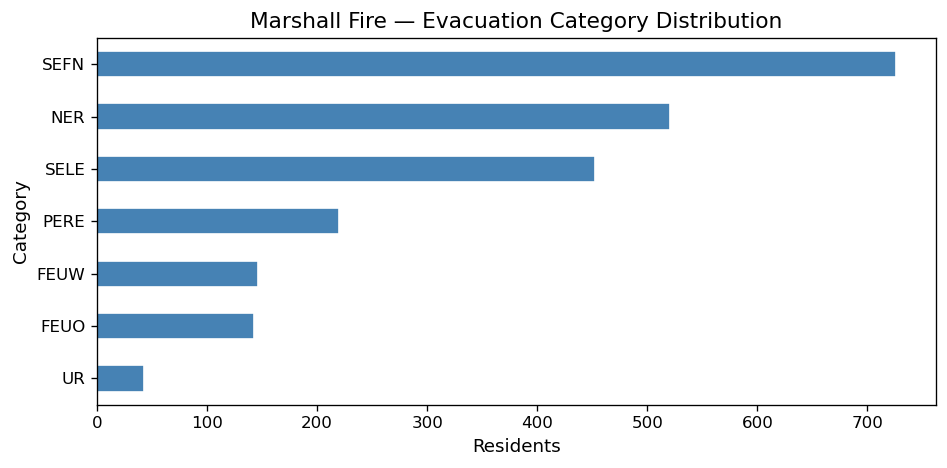

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
cat.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Residents')
ax.set_title('Marshall Fire — Evacuation Category Distribution')
plt.tight_layout()
plt.show()

---
## 9 · Cumulative Departure Curve

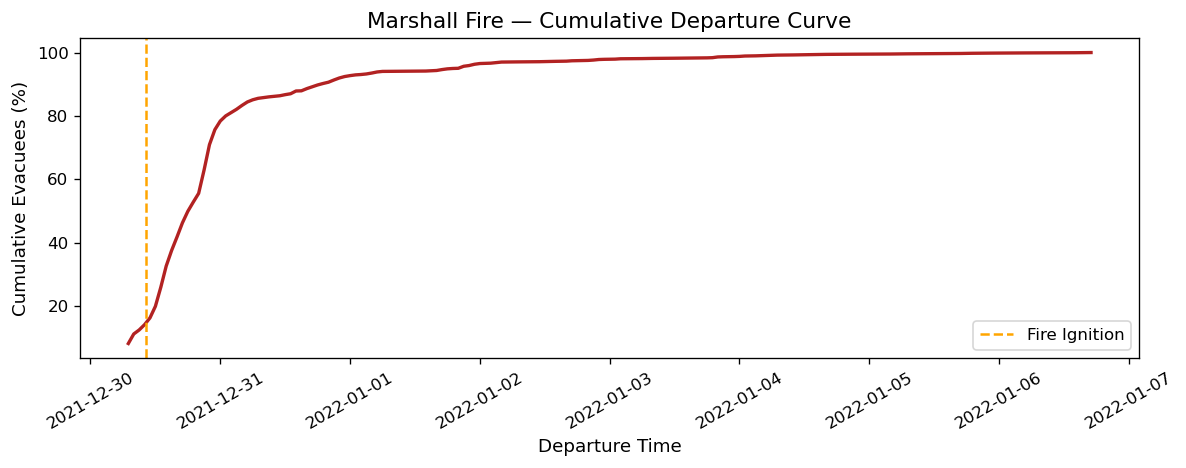

In [15]:
evacuees = metrics[metrics['is_evacuee']].dropna(subset=['DepartureDate']).copy()
evacuees['dep_hour'] = evacuees['DepartureDate'].dt.floor('h')

curve = (
    evacuees.groupby('dep_hour').size()
    .reset_index(name='departures')
    .sort_values('dep_hour')
)
curve['cumulative'] = curve['departures'].cumsum()
curve['pct']        = curve['cumulative'] / len(evacuees) * 100

fire_time = pd.Timestamp(FIRE_STARTS['Marshall'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve['dep_hour'], curve['pct'], color='firebrick', linewidth=2)
ax.axvline(fire_time, color='orange', linestyle='--', linewidth=1.5, label='Fire Ignition')
ax.set_xlabel('Departure Time')
ax.set_ylabel('Cumulative Evacuees (%)')
ax.set_title('Marshall Fire — Cumulative Departure Curve')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 10 · Delay Distribution

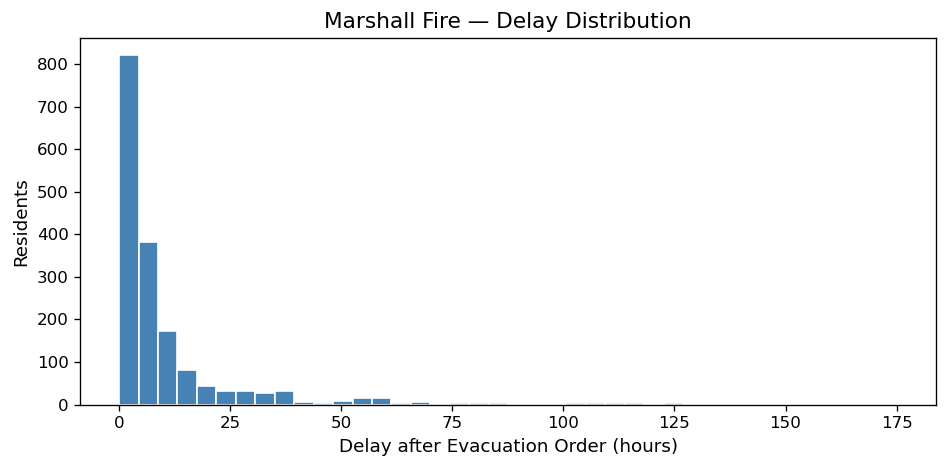

Median delay : 4.7 hrs
Mean delay   : 11.4 hrs


In [16]:
delay_df = metrics.dropna(subset=['DelayHours'])
delay_df = delay_df[delay_df['DelayHours'] >= 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delay_df['DelayHours'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Delay after Evacuation Order (hours)')
ax.set_ylabel('Residents')
ax.set_title('Marshall Fire — Delay Distribution')
plt.tight_layout()
plt.show()

print(f'Median delay : {delay_df["DelayHours"].median():.1f} hrs')
print(f'Mean delay   : {delay_df["DelayHours"].mean():.1f} hrs')